# Olist — Data-first analysis
**HVIA Task 01 · Business Discovery**

The order of work is fixed. The data decides the analysis, the analysis decides the findings.

**Files → Inspection → Data model → Cleaning → Analysis → Findings**

Nothing here assumes how many files there are, what they are called, or what columns they have.
Part 1 looks at whatever is inside the `data/` folder. Part 2 works out how the tables connect.
Only then does the analysis start, and it stops with a clear message if a needed column is missing.

**How to run:** put your data files in `data/`, then *Restart & Run All*.

## 0. Setup

In [1]:
import itertools
import json
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("../data") if Path("../data").exists() else Path("data")
CHARTS = Path("../charts") if Path("../charts").exists() else Path("charts")
CHARTS.mkdir(exist_ok=True)

NAVY, ORANGE, TEAL, GREY = "#0B1F3A", "#F26B21", "#1B9AAA", "#C9D1D9"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": NAVY, "xtick.color": NAVY,
    "ytick.color": NAVY, "font.size": 11, "axes.titleweight": "bold",
})

results = {}          # every number the presentation needs is stored here

def save(name):
    plt.tight_layout()
    plt.savefig(CHARTS / f"{name}.png", dpi=160)
    plt.show()

# PART 1 — INSPECT THE ACTUAL FILES

### 1.1 What is in the data folder?
We list every file, count them, and note the format of each one.

In [2]:
all_files = sorted(p for p in DATA.iterdir() if p.is_file())
files = pd.DataFrame({
    "file": [p.name for p in all_files],
    "format": [p.suffix.lower() for p in all_files],
    "size_mb": [round(p.stat().st_size / 1e6, 2) for p in all_files],
})
display(files)
print("Files in folder:", len(files))
print("Formats:", files["format"].value_counts().to_dict())

,file,format,size_mb
0,olist_geolocation_dataset.csv,.csv,61.27
1,olist_order_items_dataset.csv,.csv,13.19
2,olist_order_payments_dataset.csv,.csv,5.78
3,olist_order_reviews_dataset.csv,.csv,14.41
4,olist_orders_dataset.csv,.csv,17.65
5,olist_products_dataset.csv,.csv,2.38
6,olist_sellers_dataset.csv,.csv,0.17
7,product_category_name_translation.csv,.csv,0.00


Files in folder: 8
Formats: {'.csv': 8}


### 1.2 Load every data file
We load every CSV. Other file types would need their own reader, so we report them instead of guessing.

In [3]:
tables = {}
for p in all_files:
    if p.suffix.lower() == ".csv":
        tables[p.stem] = pd.read_csv(p, encoding="utf-8-sig", low_memory=False)
    else:
        print("Not loaded (not a CSV):", p.name)

print(f"\nLoaded {len(tables)} tables")


Loaded 8 tables


### 1.3 Shape, missing values and duplicates of each table

In [4]:
inventory = pd.DataFrame({
    "rows": {n: len(t) for n, t in tables.items()},
    "columns": {n: t.shape[1] for n, t in tables.items()},
    "missing_cells": {n: int(t.isna().sum().sum()) for n, t in tables.items()},
    "duplicate_rows": {n: int(t.duplicated().sum()) for n, t in tables.items()},
})
display(inventory)

,rows,columns,missing_cells,duplicate_rows
olist_geolocation_dataset,1000163,5,0,261831
olist_order_items_dataset,112650,6,0,0
olist_order_payments_dataset,103886,5,0,0
olist_order_reviews_dataset,100000,7,146532,0
olist_orders_dataset,99441,8,4908,0
olist_products_dataset,32951,9,2448,0
olist_sellers_dataset,3095,4,0,0
product_category_name_translation,71,2,0,0


### 1.4 Every column: type, missing values, unique values

In [5]:
for name, t in tables.items():
    print(f"\n{name}   shape = {t.shape}")
    profile = pd.DataFrame({"dtype": t.dtypes.astype(str), "missing": t.isna().sum(), "unique": t.nunique()})
    display(profile)


olist_geolocation_dataset   shape = (1000163, 5)


,dtype,missing,unique
geolocation_zip_code_prefix,int64,0,19015
geolocation_lat,float64,0,717360
geolocation_lng,float64,0,717613
geolocation_city,object,0,8011
geolocation_state,object,0,27



olist_order_items_dataset   shape = (112650, 6)


,dtype,missing,unique
order_id,object,0,98666
order_item_id,int64,0,21
product_id,object,0,32951
seller_id,object,0,3095
price,float64,0,5968
freight_value,float64,0,6999



olist_order_payments_dataset   shape = (103886, 5)


...

,dtype,missing,unique
product_id,object,0,32951
product_category_name,object,610,73
product_name_lenght,float64,610,66
product_description_lenght,float64,610,2960
product_photos_qty,float64,610,19
product_weight_g,float64,2,2204
product_length_cm,float64,2,99
product_height_cm,float64,2,102
product_width_cm,float64,2,95



olist_sellers_dataset   shape = (3095, 4)


,dtype,missing,unique
seller_id,object,0,3095
seller_zip_code_prefix,int64,0,2246
seller_city,object,0,611
seller_state,object,0,23



product_category_name_translation   shape = (71, 2)


,dtype,missing,unique
product_category_name,object,0,71
product_category_name_english,object,0,71


### 1.5 Grain: what does one row mean?
The grain is the smallest set of columns that makes every row unique.
We try single columns first, then pairs of ID-like columns.

In [6]:
def find_grain(t):
    for col in t.columns:
        if t[col].is_unique:
            return [col]
    id_like = [c for c in t.columns if "id" in c or "sequential" in c or "zip" in c]
    for a, b in itertools.combinations(id_like, 2):
        if not t.duplicated([a, b]).any():
            return [a, b]
    return []          # no unique key

grain = {name: find_grain(t) for name, t in tables.items()}
for name, g in grain.items():
    print(f"{name:40} one row = one {g if g else 'no unique key (has duplicate rows)'}")

olist_geolocation_dataset                one row = one no unique key (has duplicate rows)
olist_order_items_dataset                one row = one ['order_id', 'order_item_id']
olist_order_payments_dataset             one row = one ['order_id', 'payment_sequential']
olist_order_reviews_dataset              one row = one ['review_id', 'order_id']
olist_orders_dataset                     one row = one ['order_id']
olist_products_dataset                   one row = one ['product_id']
olist_sellers_dataset                    one row = one ['seller_id']
product_category_name_translation        one row = one ['product_category_name']


## PART 2 — DATA MODEL: how do the tables connect?
For every pair of tables that share a column name, we check:
how the keys relate (1:1, 1:N, N:N) and how many keys are found on both sides.
A join is **safe** only if at least one side is unique on that key.
A many-to-many join would repeat rows and inflate every total.

In [7]:
links = []
for (a, ta), (b, tb) in itertools.combinations(tables.items(), 2):
    for col in sorted(set(ta.columns) & set(tb.columns)):
        keys_a, keys_b = set(ta[col].dropna()), set(tb[col].dropna())
        both = len(keys_a & keys_b)
        a_unique, b_unique = ta[col].is_unique, tb[col].is_unique
        kind = "1:1" if a_unique and b_unique else "1:N" if a_unique else "N:1" if b_unique else "N:N"
        links.append({
            "table_a": a, "table_b": b, "column": col, "type": kind,
            "a_found_in_b_%": round(both / len(keys_a) * 100, 1),
            "b_found_in_a_%": round(both / len(keys_b) * 100, 1),
            "safe_to_join": "yes" if kind != "N:N" else "NO (rows would multiply)",
        })

links = pd.DataFrame(links)
display(links)

,table_a,table_b,column,type,a_found_in_b_%,b_found_in_a_%,safe_to_join
0,olist_order_items_dataset,olist_order_payments_dataset,order_id,N:N,100.0,99.2,NO (rows would multiply)
1,olist_order_items_dataset,olist_order_reviews_dataset,order_id,N:N,100.0,99.2,NO (rows would multiply)
2,olist_order_items_dataset,olist_orders_dataset,order_id,N:1,100.0,99.2,yes
3,olist_order_items_dataset,olist_products_dataset,product_id,N:1,100.0,100.0,yes
4,olist_order_items_dataset,olist_sellers_dataset,seller_id,N:1,100.0,100.0,yes
5,olist_order_payments_dataset,olist_order_reviews_dataset,order_id,N:N,100.0,100.0,NO (rows would multiply)
6,olist_order_payments_dataset,olist_orders_dataset,order_id,N:1,100.0,100.0,yes
7,olist_order_reviews_dataset,olist_orders_dataset,order_id,N:1,100.0,100.0,yes
8,olist_products_dataset,product_category_name_translation,product_category_name,N:1,97.3,100.0,yes


Some tables describe the same thing with **different column names** (for example a zip code).
We look for those too, using column names that contain "zip".

In [8]:
zip_cols = [(n, c) for n, t in tables.items() for c in t.columns if "zip" in c]
for (n1, c1), (n2, c2) in itertools.combinations(zip_cols, 2):
    if n1 != n2:
        a_in_b = tables[n1][c1].isin(tables[n2][c2]).mean() * 100
        b_in_a = tables[n2][c2].isin(tables[n1][c1]).mean() * 100
        print(f"{n1}.{c1}  <->  {n2}.{c2}")
        print(f"   first found in second: {a_in_b:.1f}%   second found in first: {b_in_a:.1f}%")
        print(f"   first unique? {tables[n1][c1].is_unique}   second unique? {tables[n2][c2].is_unique}")
        if not tables[n1][c1].is_unique and not tables[n2][c2].is_unique:
            print("   -> zip codes repeat on both sides: many-to-many, NOT safe to join directly")

olist_geolocation_dataset.geolocation_zip_code_prefix  <->  olist_sellers_dataset.seller_zip_code_prefix
   first found in second: 26.9%   second found in first: 99.8%
   first unique? False   second unique? False
   -> zip codes repeat on both sides: many-to-many, NOT safe to join directly


### 2.1 Which tables are which? (found by their columns, not their names)
We describe each role by the columns it must have. If a role is missing, we say so.

In [9]:
ROLES = {
    "orders":     {"order_id", "order_status", "order_purchase_timestamp"},
    "items":      {"order_id", "product_id", "seller_id", "price", "freight_value"},
    "payments":   {"order_id", "payment_type", "payment_value"},
    "reviews":    {"order_id", "review_score"},
    "products":   {"product_id", "product_category_name"},
    "sellers":    {"seller_id", "seller_state"},
    "categories": {"product_category_name", "product_category_name_english"},
}

found_tables = {}
for role, needed in ROLES.items():
    match = [n for n, t in tables.items() if needed <= set(t.columns)]
    # a role must match exactly one table, and the product table must not be the name table
    if role == "products":
        match = [n for n in match if "product_id" in tables[n].columns]
    if len(match) == 1:
        found_tables[role] = match[0]
        print(f"{role:11} -> {match[0]}")
    else:
        print(f"{role:11} -> NOT FOUND ({len(match)} matches)")

orders   = tables[found_tables["orders"]].copy()
items    = tables[found_tables["items"]].copy()
payments = tables[found_tables["payments"]].copy()
reviews  = tables[found_tables["reviews"]].copy()
products = tables[found_tables["products"]].copy()
sellers  = tables[found_tables["sellers"]].copy()
names    = tables[found_tables["categories"]].copy()

orders      -> olist_orders_dataset
items       -> olist_order_items_dataset
payments    -> olist_order_payments_dataset
reviews     -> olist_order_reviews_dataset
products    -> olist_products_dataset
sellers     -> olist_sellers_dataset
categories  -> product_category_name_translation


### 2.2 What can this data answer, and what can it not?

In [10]:
def has_column(text):
    return [f"{n}.{c}" for n, t in tables.items() for c in t.columns if text in c]

checks = {
    "Customer location (state / zip)":       has_column("customer_state") + has_column("customer_zip"),
    "Repeat buyers (customer_unique_id)":    has_column("customer_unique_id"),
    "Seller shipping deadline":              has_column("shipping_limit"),
    "Costs or margins":                      has_column("cost") + has_column("margin"),
    "Order review score":                    has_column("review_score"),
    "Delivery dates (5 timestamps)":         [c for c in orders.columns if "date" in c or "_at" in c or "timestamp" in c],
}
for question, cols in checks.items():
    print(f"{'YES' if cols else 'NO ':4} {question:40} {cols if cols else ''}")

results["can_answer"] = {q: bool(c) for q, c in checks.items()}

NO   Customer location (state / zip)          
NO   Repeat buyers (customer_unique_id)       
NO   Seller shipping deadline                 
NO   Costs or margins                         
YES  Order review score                       ['olist_order_reviews_dataset.review_score']
YES  Delivery dates (5 timestamps)            ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


### 2.3 Save the inspection summary for the presentation

In [11]:
results["files_in_folder"] = len(files)
results["data_files"] = len(tables)
results["inventory"] = [
    {"file": f"{n}.csv", "rows": int(r.rows), "cols": int(r.columns),
     "missing": int(r.missing_cells), "dups": int(r.duplicate_rows), "grain": " + ".join(grain[n]) or "none"}
    for n, r in inventory.iterrows()]
results["unsafe_joins"] = links.loc[links["type"] == "N:N", ["table_a", "table_b", "column"]].values.tolist()
results["orders_without_items"] = int((~orders["order_id"].isin(items["order_id"])).sum())
results["orders_without_payment"] = int((~orders["order_id"].isin(payments["order_id"])).sum())
results["orders_without_review"] = int((~orders["order_id"].isin(reviews["order_id"])).sum())
results["reviews_rows"] = len(reviews)
results["reviews_orders"] = int(reviews["order_id"].nunique())
results["products_without_translation"] = int((~products["product_category_name"].dropna().isin(names["product_category_name"])).sum())

# PART 3 — CLEAN THE DATA
We test the data before trusting it. Every problem found gets one clear decision.

In [12]:
date_cols = [c for c in orders.columns if "date" in c or "_at" in c or "timestamp" in c]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c])

buy, approved, carrier, customer, promised = (
    orders["order_purchase_timestamp"], orders["order_approved_at"],
    orders["order_delivered_carrier_date"], orders["order_delivered_customer_date"],
    orders["order_estimated_delivery_date"])

problems = {
    "Carrier pick-up BEFORE purchase":                 int((carrier < buy).sum()),
    "Carrier pick-up before payment approval":         int((carrier < approved).sum()),
    "Customer delivery BEFORE carrier pick-up":        int((customer < carrier).sum()),
    "Status 'delivered' but no delivery date":         int(((orders["order_status"] == "delivered") & customer.isna()).sum()),
    "Delivery date present but status not 'delivered'": int(((orders["order_status"] != "delivered") & customer.notna()).sum()),
}
review_dates = reviews.merge(orders[["order_id", "order_purchase_timestamp"]], on="order_id")
problems["Review written BEFORE the purchase"] = int(
    (pd.to_datetime(review_dates["review_creation_date"]) < review_dates["order_purchase_timestamp"]).sum())
problems["Orders with 2+ review rows"] = int((reviews.groupby("order_id").size() > 1).sum())
problems["Rows with a review_id used by another order"] = int(reviews["review_id"].duplicated().sum())
problems["Products whose category has no English name"] = results["products_without_translation"]

display(pd.Series(problems, name="rows affected"))
results["problems"] = problems

Carrier pick-up BEFORE purchase                      166
Carrier pick-up before payment approval             1359
Customer delivery BEFORE carrier pick-up              23
Status 'delivered' but no delivery date                8
Delivery date present but status not 'delivered'       6
Review written BEFORE the purchase                    75
Orders with 2+ review rows                           555
Rows with a review_id used by another order          827
Products whose category has no English name           13
Name: rows affected, dtype: int64

**Decisions**

| Problem | What we do |
|:--|:--|
| Carrier pick-up before payment approval | Normal (sellers can ship before a boleto clears). So "seller handling" = purchase → pick-up, not approval → pick-up |
| Pick-up before purchase / delivery before pick-up | Impossible. We blank that one duration only, not the whole order |
| Review before the purchase | Impossible. Removed |
| 2+ reviews on one order | Keep the **latest** review (the customer's final opinion) |
| Delivery date present, status not delivered | We trust the date. "Delivered" = has a delivery date |
| Sparse months (2016 and Sep–Oct 2018) | Left out of trend charts only |

In [13]:
# Reviews: drop impossible ones, then keep the latest review per order
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews = reviews.merge(orders[["order_id", "order_purchase_timestamp"]], on="order_id")
reviews = reviews[reviews["review_creation_date"] >= reviews["order_purchase_timestamp"]]
reviews = reviews.sort_values(["review_creation_date", "review_answer_timestamp"])
last_review = reviews.drop_duplicates("order_id", keep="last").set_index("order_id")["review_score"].rename("score")
orders = orders.merge(last_review, on="order_id", how="left")

# Durations in days. Impossible (negative) ones become empty
def days(later, earlier):
    d = (later - earlier).dt.total_seconds() / 86400
    return d.where(d >= 0)

orders["approval_days"] = days(orders["order_approved_at"], orders["order_purchase_timestamp"])
orders["handling_days"] = days(orders["order_delivered_carrier_date"], orders["order_purchase_timestamp"])
orders["transit_days"]  = days(orders["order_delivered_customer_date"], orders["order_delivered_carrier_date"])
orders["total_days"]    = days(orders["order_delivered_customer_date"], orders["order_purchase_timestamp"])
orders["promised_days"] = days(orders["order_estimated_delivery_date"], orders["order_purchase_timestamp"])
orders["days_late"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.total_seconds() / 86400

# Outcome of each order
delivered = orders["order_delivered_customer_date"].notna()
orders["outcome"] = np.where(~delivered, "Never arrived", np.where(orders["days_late"] > 0, "Late", "On time"))
orders["bad_review"] = orders["score"] <= 2       # 1 or 2 stars
reviewed = orders[orders["score"].notna()]

print(orders["outcome"].value_counts())
print("Orders with a usable review:", len(reviewed))

outcome
On time          88649
Late              7827
Never arrived     2965
Name: count, dtype: int64
Orders with a usable review: 99369


# PART 4 — ANALYSIS
Each question uses only what Part 2 proved is available.

## Headline numbers

In [14]:
valid_orders = orders.loc[~orders["order_status"].isin(["canceled", "unavailable"]), "order_id"]
sales = items.loc[items["order_id"].isin(valid_orders), "price"].sum()

results["orders"] = len(orders)
results["sellers"] = len(sellers)
results["sales_millions"] = round(sales / 1e6, 2)
results["avg_score"] = round(reviewed["score"].mean(), 2)
results["late_orders"] = int((orders["outcome"] == "Late").sum())
results["late_rate"] = round(results["late_orders"] / delivered.sum() * 100, 1)
results["never_arrived"] = int((orders["outcome"] == "Never arrived").sum())
results["never_by_status"] = orders.loc[orders["outcome"] == "Never arrived", "order_status"].value_counts().to_dict()

print(f"Orders {len(orders):,} | sales R$ {sales/1e6:.1f}M | avg score {results['avg_score']}")
print(f"Late {results['late_orders']:,} ({results['late_rate']}% of delivered) | never arrived {results['never_arrived']:,}")

Orders 99,441 | sales R$ 13.5M | avg score 4.07
Late 7,827 (8.1% of delivered) | never arrived 2,965


## Q1. Is the business growing?
We only read Jan 2017 – Aug 2018. Months outside that range have very few orders.

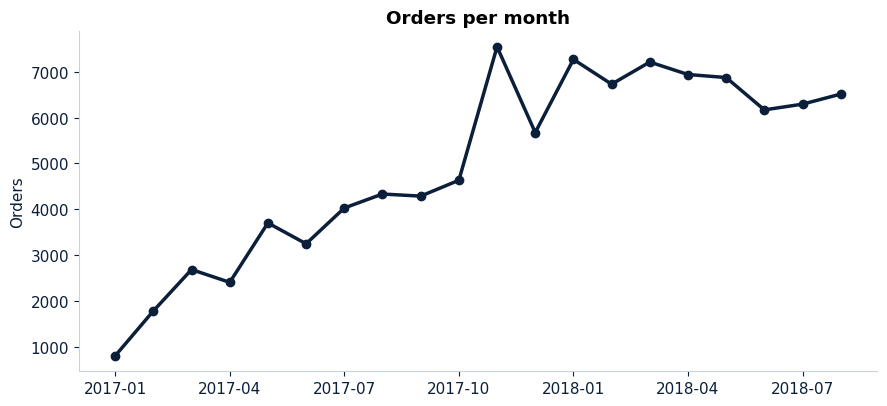

Growth Jan–Aug 2018 vs 2017: +135% | peak 2017-11: 7,544


In [15]:
month = orders["order_purchase_timestamp"].dt.to_period("M")
monthly = orders[(month >= "2017-01") & (month <= "2018-08")].groupby(month).size()

plt.figure(figsize=(9, 4.2))
plt.plot(monthly.index.astype(str), monthly.values, color=NAVY, marker="o", linewidth=2.5)
plt.xticks(range(0, len(monthly), 3), monthly.index.astype(str)[::3])
plt.title("Orders per month")
plt.ylabel("Orders")
save("q1_orders_per_month")

results["monthly_orders"] = {str(k): int(v) for k, v in monthly.items()}
results["growth_pct"] = round((monthly["2018-01":"2018-08"].sum() / monthly["2017-01":"2017-08"].sum() - 1) * 100)
results["peak_month"] = str(monthly.idxmax())
results["peak_orders"] = int(monthly.max())
results["orders_2018_avg"] = round(monthly["2018-01":"2018-08"].mean())
print(f"Growth Jan–Aug 2018 vs 2017: +{results['growth_pct']}% | peak {results['peak_month']}: {results['peak_orders']:,}")

## Q2. Does Olist deliver on its promise?

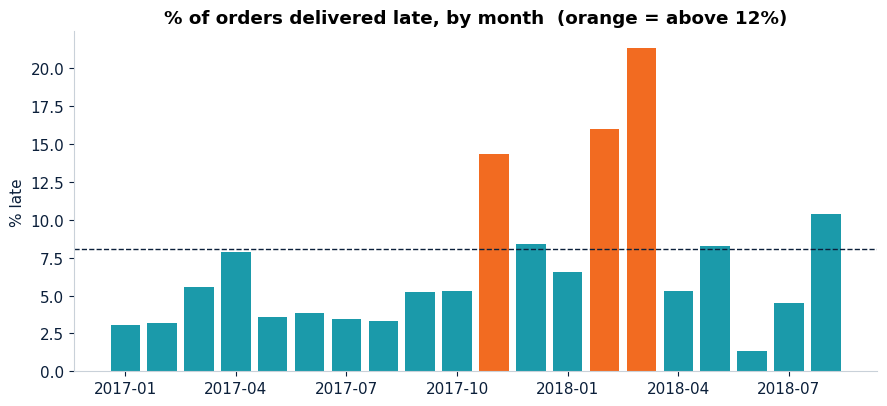

Promised 23.7 days, delivered in 12.6 days
Months above 12% late: ['2017-11', '2018-02', '2018-03']


In [16]:
got_it = orders[delivered]
results["promised_days"] = round(got_it["promised_days"].mean(), 1)
results["actual_days"] = round(got_it["total_days"].mean(), 1)

m = month[delivered]
late_by_month = (got_it[(m >= "2017-01") & (m <= "2018-08")]
                 .groupby(m)["days_late"].apply(lambda x: (x > 0).mean() * 100))

plt.figure(figsize=(9, 4.2))
plt.bar(late_by_month.index.astype(str), late_by_month.values,
        color=[ORANGE if v > 12 else TEAL for v in late_by_month.values])
plt.xticks(range(0, len(late_by_month), 3), late_by_month.index.astype(str)[::3])
plt.axhline(results["late_rate"], color=NAVY, linestyle="--", linewidth=1)
plt.title("% of orders delivered late, by month  (orange = above 12%)")
plt.ylabel("% late")
save("q2_late_by_month")

results["late_by_month"] = {str(k): round(v, 1) for k, v in late_by_month.items()}
results["worst_month"] = str(late_by_month.idxmax())
results["worst_month_rate"] = round(late_by_month.max(), 1)
results["bad_months"] = [str(k) for k, v in late_by_month.items() if v > 12]
print(f"Promised {results['promised_days']} days, delivered in {results['actual_days']} days")
print("Months above 12% late:", results["bad_months"])

## Q3. How much does lateness hurt the review score?

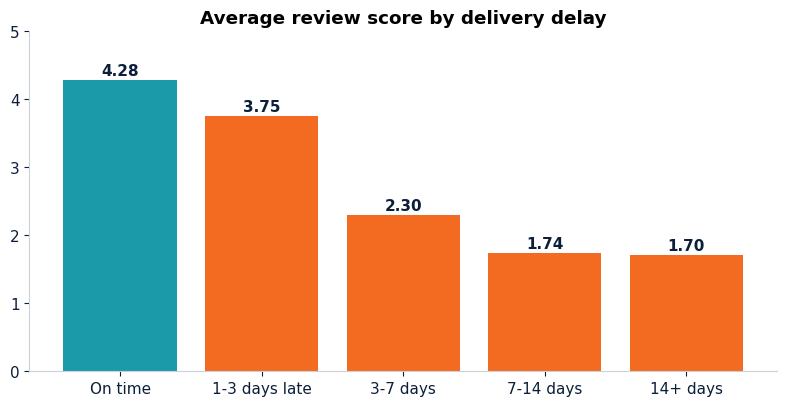

outcome
Late             54.6
Never arrived    78.3
On time           9.5
Name: bad_review, dtype: float64


In [17]:
arrived = reviewed[reviewed["outcome"] != "Never arrived"]
bucket = pd.cut(arrived["days_late"], [-1e9, 0, 3, 7, 14, 1e9],
                labels=["On time", "1-3 days late", "3-7 days", "7-14 days", "14+ days"])
score_by_bucket = arrived.groupby(bucket, observed=True)["score"].mean()

plt.figure(figsize=(8, 4.2))
plt.bar(score_by_bucket.index, score_by_bucket.values, color=[TEAL] + [ORANGE] * 4)
for i, v in enumerate(score_by_bucket.values):
    plt.text(i, v + 0.08, f"{v:.2f}", ha="center", fontweight="bold", color=NAVY)
plt.ylim(0, 5)
plt.title("Average review score by delivery delay")
save("q3_score_by_delay")

bad_rate = reviewed.groupby("outcome")["bad_review"].mean() * 100
results["score_by_delay"] = {str(k): round(v, 2) for k, v in score_by_bucket.items()}
results["bad_rate"] = {k: round(v, 1) for k, v in bad_rate.items()}
print(bad_rate.round(1))

## Q4. Where do ALL the bad reviews come from?
Late orders are not the only delivery problem. Orders that **never arrived** are even angrier.

,orders,bad,avg_score,share_of_orders,share_of_bad_reviews
outcome,,,,,
Late,7827,4275,2.5,7.9,28.6
Never arrived,2896,2269,1.7,2.9,15.2
On time,88646,8419,4.3,89.2,56.3


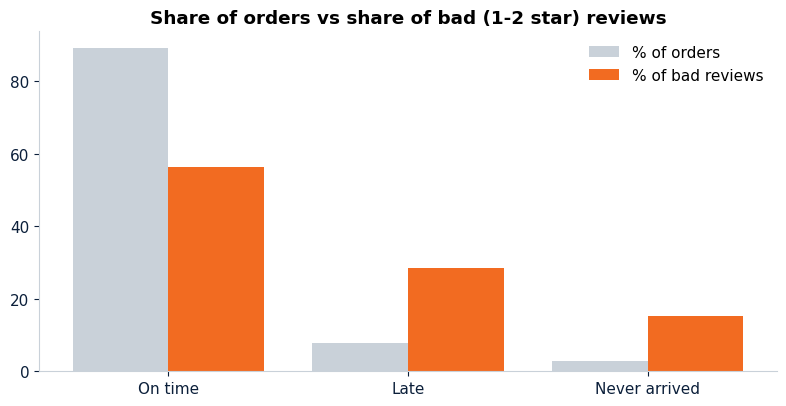

In [18]:
groups = reviewed.groupby("outcome").agg(
    orders=("order_id", "count"), bad=("bad_review", "sum"), avg_score=("score", "mean"))
groups["share_of_orders"] = groups["orders"] / groups["orders"].sum() * 100
groups["share_of_bad_reviews"] = groups["bad"] / groups["bad"].sum() * 100
display(groups.round(1))

order = ["On time", "Late", "Never arrived"]
x = np.arange(3)
plt.figure(figsize=(8, 4.2))
plt.bar(x - 0.2, groups.loc[order, "share_of_orders"], 0.4, label="% of orders", color=GREY)
plt.bar(x + 0.2, groups.loc[order, "share_of_bad_reviews"], 0.4, label="% of bad reviews", color=ORANGE)
plt.xticks(x, order)
plt.legend(frameon=False)
plt.title("Share of orders vs share of bad (1-2 star) reviews")
save("q4_bad_review_sources")

results["orders_share"] = {k: round(v, 1) for k, v in groups["share_of_orders"].items()}
results["bad_share"] = {k: round(v, 1) for k, v in groups["share_of_bad_reviews"].items()}
results["fail_order_share"] = round(100 - results["orders_share"]["On time"], 1)
results["fail_bad_share"] = round(100 - results["bad_share"]["On time"], 1)
results["bad_reviews_total"] = int(groups["bad"].sum())
results["avg_score_never"] = round(groups.loc["Never arrived", "avg_score"], 2)
results["one_quarter_late_saves_pct"] = round(groups.loc["Late", "bad"] * 0.25 / groups["bad"].sum() * 100, 1)

## Q5. Where does the delivery time go?
Purchase → payment approval → seller hands over to carrier → carrier delivers.

,approval_days,handling_days,transit_days
outcome,,,
On time,0.4,2.6,7.9
Late,0.5,5.3,25.7


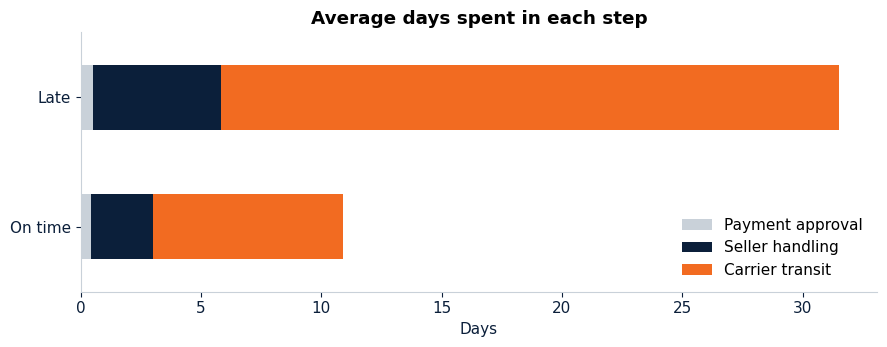

Late rate if hand-over takes 5+ days: 16.6%  |  otherwise: 6.3%


In [19]:
step = ["approval_days", "handling_days", "transit_days"]
parts = orders[delivered & (orders["outcome"] != "Never arrived")].groupby("outcome")[step].mean().loc[["On time", "Late"]]
# handling starts at purchase, so approval is already inside it: we show handling without the approval part
parts["handling_days"] = parts["handling_days"] - parts["approval_days"]
display(parts.round(1))

parts.plot(kind="barh", stacked=True, color=[GREY, NAVY, ORANGE], figsize=(9, 3.6))
plt.legend(["Payment approval", "Seller handling", "Carrier transit"], frameon=False, loc="lower right")
plt.title("Average days spent in each step")
plt.xlabel("Days")
plt.ylabel("")
save("q5_time_breakdown")

# Does a slow hand-over predict a late order?
has_handling = orders[delivered & orders["handling_days"].notna()]
slow = has_handling["handling_days"] >= 5
results["parts"] = parts.round(1).to_dict()
results["late_if_slow"] = round((has_handling.loc[slow, "days_late"] > 0).mean() * 100, 1)
results["late_if_fast"] = round((has_handling.loc[~slow, "days_late"] > 0).mean() * 100, 1)
results["slow_share"] = round(slow.mean() * 100, 1)
results["transit_multiple"] = round(parts.loc["Late", "transit_days"] / parts.loc["On time", "transit_days"], 1)
print(f"Late rate if hand-over takes 5+ days: {results['late_if_slow']}%  |  otherwise: {results['late_if_fast']}%")

## Q6. Are a few sellers causing the problems?
We score sellers with **30+ orders**. Smaller sellers have too little data to judge.

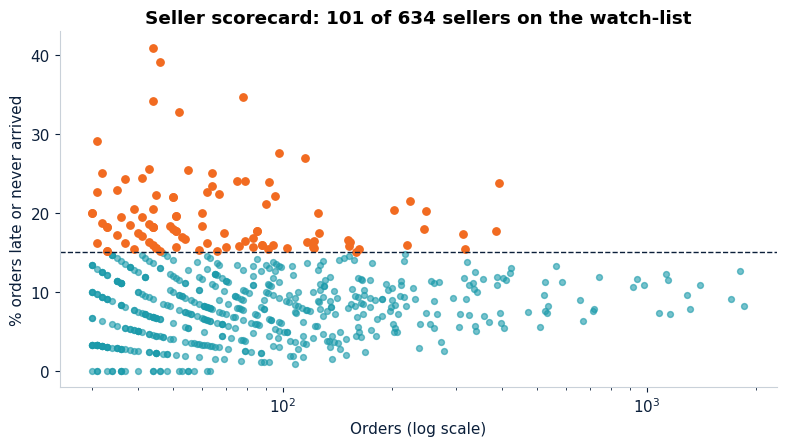

101 of 634 scored sellers on the watch-list, holding 8.2% of sales


In [20]:
seller_orders = items.groupby(["seller_id", "order_id"], as_index=False).agg(sales=("price", "sum"))
seller_orders = seller_orders.merge(orders[["order_id", "outcome", "score"]], on="order_id")
seller_orders["problem"] = seller_orders["outcome"] != "On time"

seller_table = seller_orders.groupby("seller_id").agg(
    orders=("order_id", "count"), sales=("sales", "sum"),
    problem_rate=("problem", "mean"), avg_score=("score", "mean")).reset_index()
seller_table = seller_table.merge(sellers[["seller_id", "seller_state"]], on="seller_id")

scored = seller_table[seller_table["orders"] >= 30]
watch = scored[scored["problem_rate"] >= 0.15]      # rule: 15%+ of orders late or never arrived

plt.figure(figsize=(8, 4.6))
plt.scatter(scored["orders"], scored["problem_rate"] * 100, s=18, color=TEAL, alpha=0.6)
plt.scatter(watch["orders"], watch["problem_rate"] * 100, s=28, color=ORANGE)
plt.axhline(15, color=NAVY, linestyle="--", linewidth=1)
plt.xscale("log")
plt.xlabel("Orders (log scale)")
plt.ylabel("% orders late or never arrived")
plt.title(f"Seller scorecard: {len(watch)} of {len(scored)} sellers on the watch-list")
save("q6_seller_scorecard")

total_sales = seller_table["sales"].sum()
top = seller_table["sales"].sort_values(ascending=False)
results["sellers_scored"] = len(scored)
results["scored_sales_share"] = round(scored["sales"].sum() / total_sales * 100)
results["watch_sellers"] = len(watch)
results["watch_sales_share"] = round(watch["sales"].sum() / total_sales * 100, 1)
results["avg_problem_rate_scored"] = round(scored["problem_rate"].mean() * 100, 1)
results["top10pct_sales_share"] = round(top.head(int(len(top) * 0.1)).sum() / total_sales * 100)
results["median_seller_orders"] = int(seller_table["orders"].median())
results["sp_seller_share"] = round((sellers["seller_state"] == "SP").mean() * 100)
print(f"{len(watch)} of {len(scored)} scored sellers on the watch-list, holding {results['watch_sales_share']}% of sales")

## Q7. Do orders with more than one seller go wrong?
We look at **on-time** orders only, so delivery delay cannot be the reason.

,orders,score
type,,
1 seller,87389,4.30
2+ sellers,1257,2.86


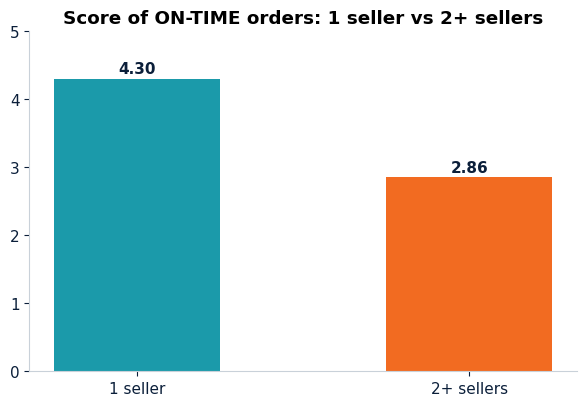

In [21]:
n_sellers = items.groupby("order_id")["seller_id"].nunique().rename("n_sellers")
on_time = reviewed[reviewed["outcome"] == "On time"].merge(n_sellers, on="order_id")
on_time["type"] = np.where(on_time["n_sellers"] > 1, "2+ sellers", "1 seller")
by_type = on_time.groupby("type").agg(orders=("score", "size"), score=("score", "mean"))
display(by_type.round(2))

plt.figure(figsize=(6, 4.2))
plt.bar(by_type.index, by_type["score"], color=[TEAL, ORANGE], width=0.5)
for i, v in enumerate(by_type["score"]):
    plt.text(i, v + 0.08, f"{v:.2f}", ha="center", fontweight="bold", color=NAVY)
plt.ylim(0, 5)
plt.title("Score of ON-TIME orders: 1 seller vs 2+ sellers")
save("q7_multi_seller")

results["score_1_seller"] = round(by_type.loc["1 seller", "score"], 2)
results["score_multi_seller"] = round(by_type.loc["2+ sellers", "score"], 2)
results["multi_seller_orders"] = int(by_type.loc["2+ sellers", "orders"])

## Q8. What do unhappy customers write?
We read the comments of 1–2 star reviews (Portuguese) and count simple keywords.
One comment can match several themes, so the numbers do not add up to 100%.
This is a rough count, good for direction, not for exact percentages.

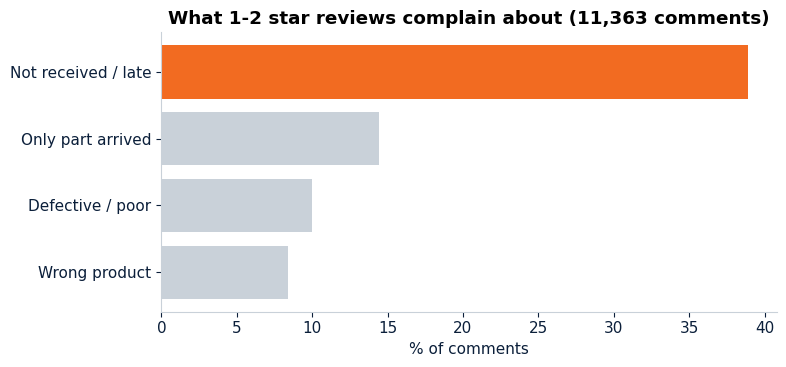

In [22]:
def clean_text(text):
    return unicodedata.normalize("NFKD", str(text).lower()).encode("ascii", "ignore").decode()

themes = {
    "Not received / late": r"nao recebi|nao chegou|ainda nao|atras|prazo|demor|nao entreg|aguardando",
    "Only part arrived":   r"apenas|somente|so recebi|faltou|falta|incomplet|um dos",
    "Defective / poor":    r"defeito|quebrad|danificad|nao funciona|qualidade|estragad|ruim",
    "Wrong product":       r"diferente|errad|outro produto|nao e o|nao corresponde|trocad",
}
comments = reviews[(reviews["review_score"] <= 2) & reviews["review_comment_message"].notna()].copy()
comments["text"] = comments["review_comment_message"].map(clean_text)

theme_share = pd.Series({t: comments["text"].str.contains(p).mean() * 100 for t, p in themes.items()}).sort_values()
no_theme = (~pd.concat([comments["text"].str.contains(p) for p in themes.values()], axis=1).any(axis=1)).mean() * 100

plt.figure(figsize=(8, 3.8))
plt.barh(theme_share.index, theme_share.values, color=[GREY, GREY, GREY, ORANGE])
plt.title(f"What 1-2 star reviews complain about ({len(comments):,} comments)")
plt.xlabel("% of comments")
save("q8_complaints")

results["complaints"] = {k: round(v, 1) for k, v in theme_share.items()}
results["comments_read"] = len(comments)
results["comments_no_theme"] = round(no_theme, 1)

## Q9. Two smaller frictions: shipping cost and payment approval

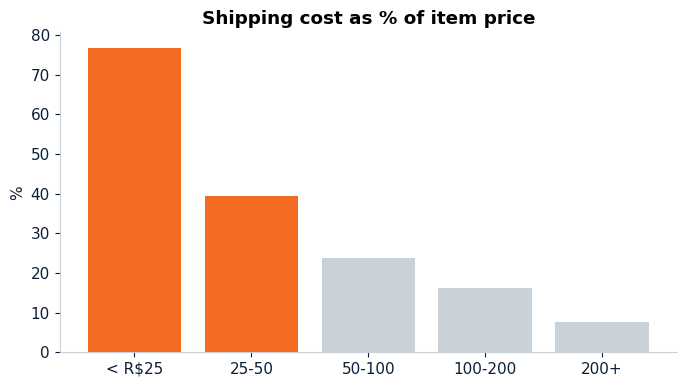

{'< R$25': 77, '25-50': 39, '50-100': 24, '100-200': 16, '200+': 8} {'boleto': 1.38, 'credit_card': 0.19, 'debit_card': 0.4, 'voucher': 0.35}


In [23]:
items["price_band"] = pd.cut(items["price"], [0, 25, 50, 100, 200, 1e6], labels=["< R$25", "25-50", "50-100", "100-200", "200+"])
freight = items.groupby("price_band", observed=True).apply(
    lambda g: g["freight_value"].sum() / g["price"].sum() * 100, include_groups=False)

plt.figure(figsize=(7, 4))
plt.bar(freight.index.astype(str), freight.values, color=[ORANGE, ORANGE, GREY, GREY, GREY])
plt.title("Shipping cost as % of item price")
plt.ylabel("%")
save("q9_freight")

pay_type = payments.groupby("order_id")["payment_type"].first()
approval = orders.merge(pay_type, on="order_id")
approval = approval[approval["payment_type"] != "not_defined"]

results["freight_by_price"] = {str(k): round(v) for k, v in freight.items()}
results["freight_overall"] = round(items["freight_value"].sum() / items["price"].sum() * 100, 1)
results["approval_by_payment"] = approval.groupby("payment_type")["approval_days"].mean().round(2).to_dict()
print(results["freight_by_price"], results["approval_by_payment"])

## Save the numbers for the presentation

In [24]:
with open(CHARTS.parent / "results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("Saved results.json with", len(results), "entries")

Saved results.json with 62 entries
